## 0. Setup and Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score, accuracy_score)
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

np.random.seed(42)
tf.random.set_seed(42)


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Task 1: Load CIFAR-10 Dataset
- Display ten sample images
- Print dataset dimensions
- Plot class distribution


In [ ]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()
y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)
print("Number of classes:", len(class_names))


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1426s 8us/step
Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000,)
Testing images shape: (10000, 32, 32, 3)
Testing labels shape: (10000,)
Number of classes: 10


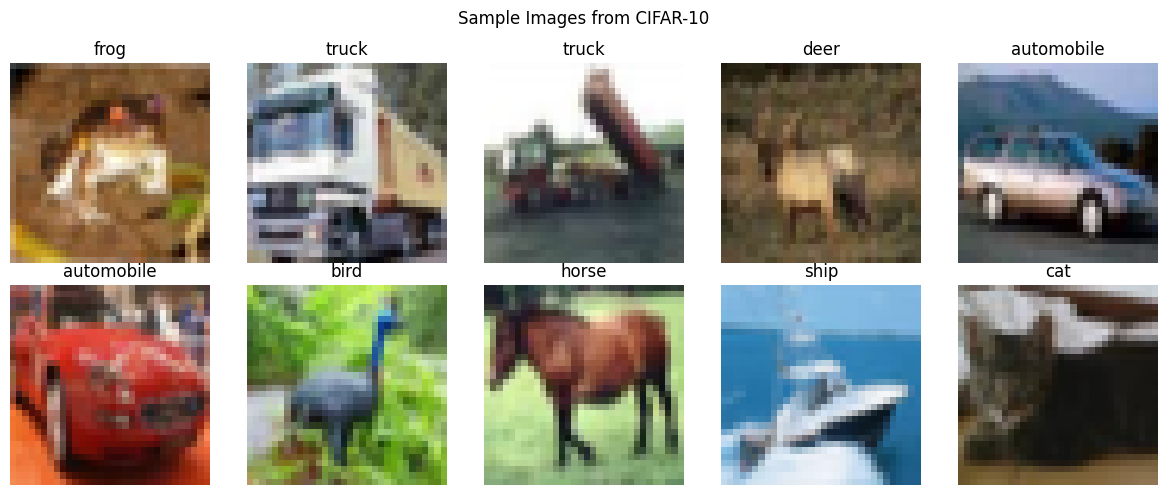

In [ ]:
# Display ten sample images
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle("Sample Images from CIFAR-10")
plt.tight_layout()
plt.show()


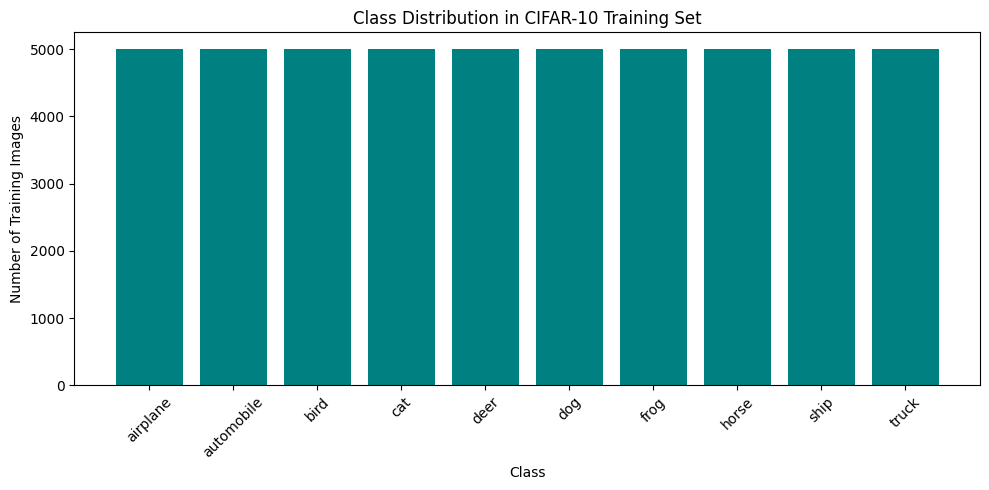

In [ ]:
# Class distribution plot
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10, 5))
plt.bar([class_names[u] for u in unique], counts, color='teal')
plt.xlabel("Class")
plt.ylabel("Number of Training Images")
plt.title("Class Distribution in CIFAR-10 Training Set")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Inference:** CIFAR-10 is a balanced dataset with exactly 5,000 training images per class, so no class-imbalance correction is required before training.

## Preprocessing: Normalize Pixel Values

In [ ]:
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0
print("Pixel value range after normalization:", x_train_norm.min(), "-", x_train_norm.max())


Pixel value range after normalization: 0.0 - 1.0


## Numerical Example 1: Convolution (Manual Verification)

Input:
$$X = \begin{bmatrix}1&2&3\\4&5&6\\7&8&9\end{bmatrix}, \quad K = \begin{bmatrix}1&0\\0&1\end{bmatrix}$$

Expected feature map: $\begin{bmatrix}6&8\\12&14\end{bmatrix}$


In [ ]:
def manual_convolve2d(X, K):
    kh, kw = K.shape
    h, w = X.shape
    out_h, out_w = h - kh + 1, w - kw + 1
    Y = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            Y[i, j] = np.sum(X[i:i+kh, j:j+kw] * K)
    return Y

X = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]], dtype=float)
K = np.array([[1, 0],
              [0, 1]], dtype=float)

Y = manual_convolve2d(X, K)
print("Feature Map:\n", Y)


Feature Map:
 [[ 6.  8.]
 [12. 14.]]


## Numerical Example 2: Max Pooling (Manual Verification)

Feature map:
$$\begin{bmatrix}1&5&2&3\\7&8&1&0\\4&6&9&5\\2&3&1&8\end{bmatrix}$$

Expected 2x2 max-pooled output: $\begin{bmatrix}8&3\\6&9\end{bmatrix}$


In [ ]:
def manual_max_pool(X, size=2, stride=2):
    h, w = X.shape
    out_h = (h - size) // stride + 1
    out_w = (w - size) // stride + 1
    Y = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            window = X[i*stride:i*stride+size, j*stride:j*stride+size]
            Y[i, j] = np.max(window)
    return Y

fmap = np.array([[1, 5, 2, 3],
                  [7, 8, 1, 0],
                  [4, 6, 9, 5],
                  [2, 3, 1, 8]], dtype=float)

pooled = manual_max_pool(fmap)
print("Max Pooled Output:\n", pooled)


Max Pooled Output:
 [[8. 3.]
 [6. 9.]]


## Numerical Example 3: Parameter Calculation

Input: 32x32x3, Conv layer: 16 filters of size 3x3

$$\text{Parameters} = (3 \times 3 \times 3 + 1) \times 16 = 448$$


In [ ]:
def conv_params(kernel_h, kernel_w, in_channels, num_filters):
    return (kernel_h * kernel_w * in_channels + 1) * num_filters

params = conv_params(3, 3, 3, 16)
print("Total trainable parameters:", params)


Total trainable parameters: 448


## Common Convolution Kernels Applied to a Sample Image
Below we apply several classical kernels (Identity, Sobel-X, Sobel-Y, Laplacian, Sharpen, Box Blur, Gaussian Blur, Emboss, Outline) to a sample CIFAR-10 image (converted to grayscale) to visualize how each kernel highlights different image characteristics.


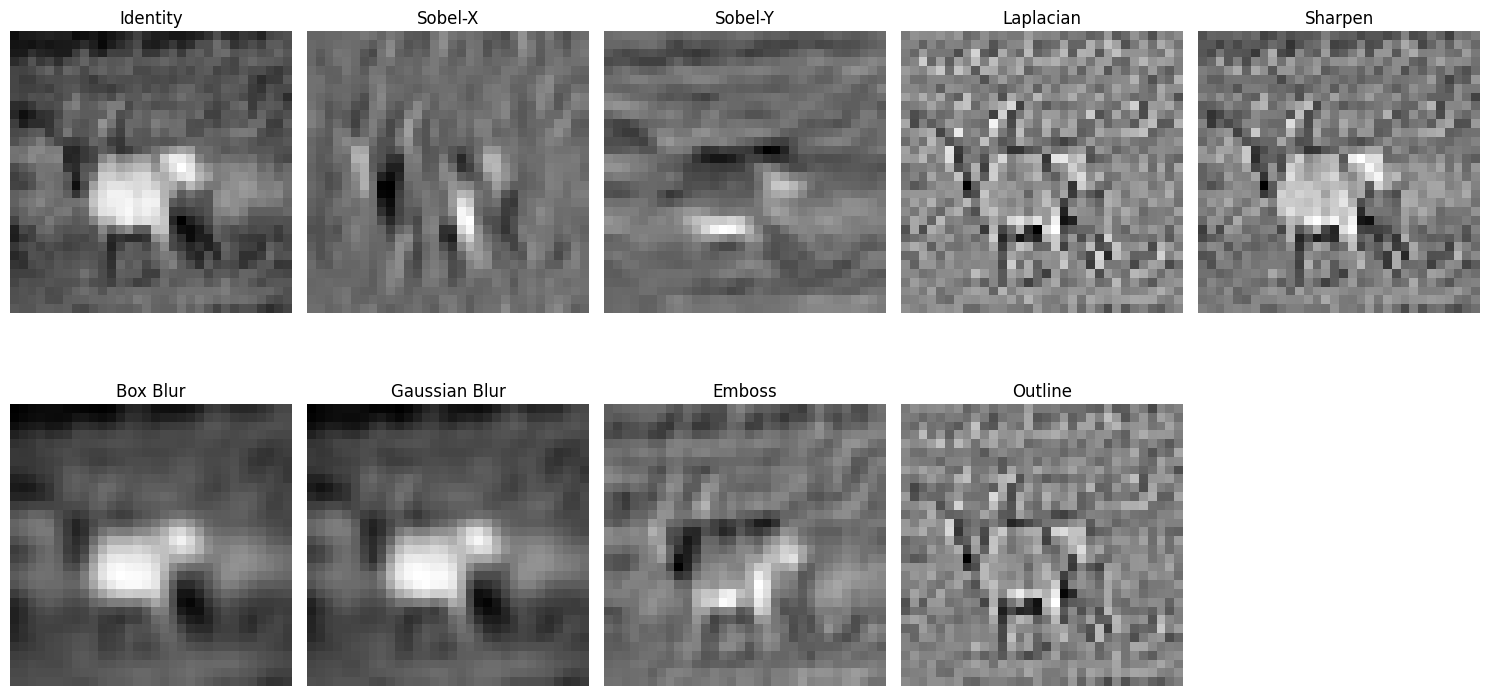

In [ ]:
from scipy.signal import convolve2d

def to_gray(img):
    return np.dot(img[..., :3], [0.299, 0.587, 0.114])

sample_img = to_gray(x_train[3])

kernels = {
    "Identity": np.array([[0,0,0],[0,1,0],[0,0,0]]),
    "Sobel-X": np.array([[-1,0,1],[-2,0,2],[-1,0,1]]),
    "Sobel-Y": np.array([[-1,-2,-1],[0,0,0],[1,2,1]]),
    "Laplacian": np.array([[0,-1,0],[-1,4,-1],[0,-1,0]]),
    "Sharpen": np.array([[0,-1,0],[-1,5,-1],[0,-1,0]]),
    "Box Blur": (1/9) * np.ones((3,3)),
    "Gaussian Blur": (1/16) * np.array([[1,2,1],[2,4,2],[1,2,1]]),
    "Emboss": np.array([[-2,-1,0],[-1,1,1],[0,1,2]]),
    "Outline": np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]])
}

plt.figure(figsize=(15,8))

for i, (name, kernel) in enumerate(kernels.items()):
    output = convolve2d(sample_img, kernel, mode='same', boundary='symm')
    plt.subplot(2,5,i+1)
    plt.imshow(output, cmap='gray')
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Task 2: Implement a Convolution Layer — Compare Kernel Sizes (3x3, 5x5, 7x7)
Record the feature map sizes produced by each kernel size (valid padding, stride 1) on a 32x32x3 input.


In [ ]:
kernel_sizes = [3, 5, 7]

input_size = 32
stride = 1
padding = 0

print(f"{'Kernel':<10}{'Output Size'}")

for k in kernel_sizes:
    output = (input_size - k + 2 * padding) // stride + 1
    print(f"{k}x{k:<6}{output} x {output}")

Kernel    Output Size
3x3     30 x 30
5x5     28 x 28
7x7     26 x 26


## Task 3: Study Hyperparameters — Stride and Padding
Compare stride = 1 vs stride = 2, and padding = 'same' vs padding = 'valid'. Output size formula:

$$\text{Output} = \frac{N - F + 2P}{S} + 1$$


In [ ]:
def output_size(N, F, P, S):
    return (N - F + 2 * P) // S + 1

print("Output feature map sizes:")

for stride in [1, 2]:
    for padding in [0, 1]:
        size = output_size(32, 3, padding, stride)
        print(f"Stride={stride}, Padding={padding}: {size} x {size}")

Output feature map sizes:
Stride=1, Padding=0: 30 x 30
Stride=1, Padding=1: 32 x 32
Stride=2, Padding=0: 15 x 15
Stride=2, Padding=1: 16 x 16


**Additional Exercise 1:** Output size for a 64x64 image, 5x5 kernel, stride 2, padding 2.

In [ ]:
N, F, P, S = 64, 5, 2, 2
size = output_size(N, F, P, S)
print(f"Output size = {size}x{size}")


Output size = 32x32


**Additional Exercise 2:** Trainable parameters for a conv layer with 64 filters of size 3x3, RGB input.

In [ ]:
params_ex2 = conv_params(3, 3, 3, 64)
print("Trainable parameters:", params_ex2)


Trainable parameters: 1792


## Task 4: Visualize Feature Maps After the First Convolution Layer
Build a small feature-extraction model using the first convolution layer and display at least eight feature maps for a sample image.


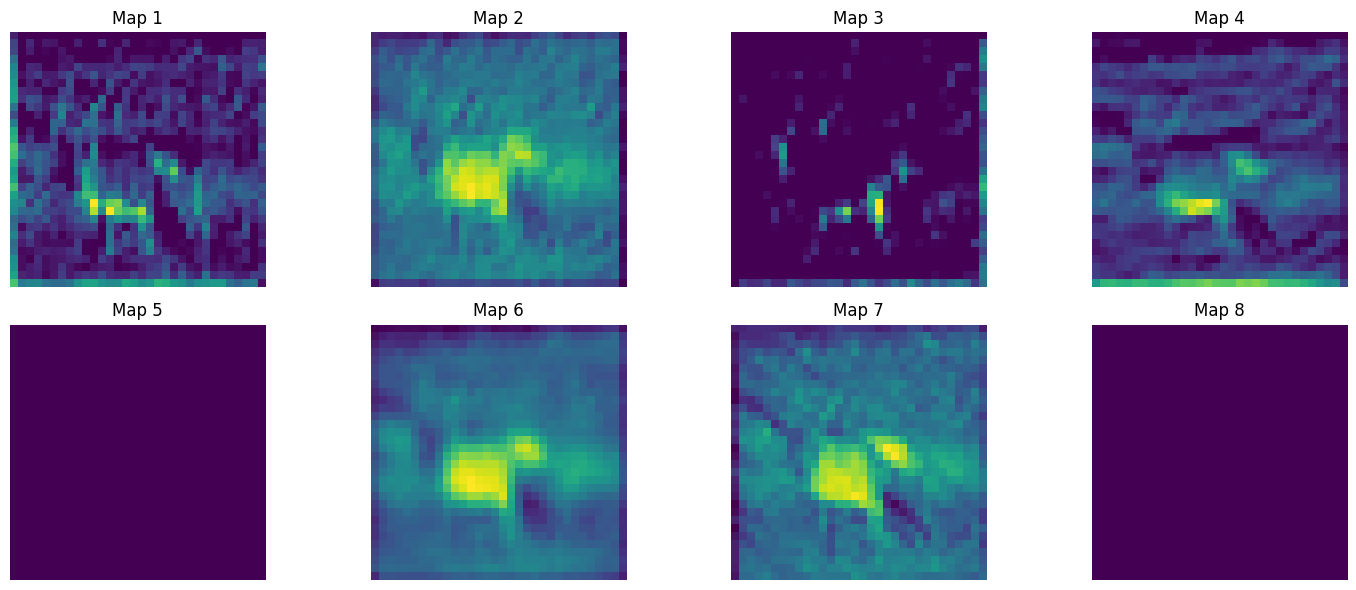

In [ ]:
feature_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(8, (3, 3), activation='relu', padding='same')
])

sample = np.expand_dims(x_train_norm[3], axis=0)
feature_maps = feature_model.predict(sample, verbose=0)

plt.figure(figsize=(15,6))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.title(f"Map {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Inference:** Each feature map activates on a different learned pattern (edges, colour contrasts, textures) in the input image; because the filters are randomly initialized at this stage, the maps highlight generic low-level structures rather than class-specific features.

## Task 5: Compare Max Pooling and Average Pooling
Compare output size (identical for both) and the resulting effect on a feature map / classification accuracy.


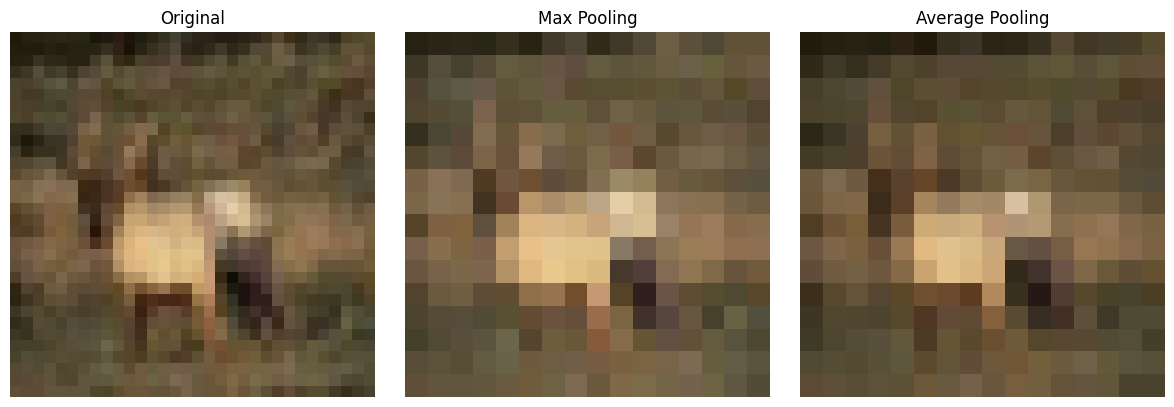

In [ ]:
pool_input = np.expand_dims(x_train_norm[3], axis=0)

max_pool = layers.MaxPooling2D(pool_size=(2,2))
avg_pool = layers.AveragePooling2D(pool_size=(2,2))

max_out = max_pool(pool_input)
avg_out = avg_pool(pool_input)

fig, axes = plt.subplots(1,3, figsize=(12,4))

axes[0].imshow(x_train[3])
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(max_out[0].numpy())
axes[1].set_title("Max Pooling")
axes[1].axis("off")

axes[2].imshow(avg_out[0].numpy())
axes[2].set_title("Average Pooling")
axes[2].axis("off")

plt.tight_layout()
plt.show()

**Inference:** Max pooling preserves the strongest (sharpest) activations and tends to retain edges/texture more distinctly, while average pooling smooths the feature map. Both reduce spatial dimensions identically; their effect on classification accuracy is compared quantitatively in Task 6/7 below by training two versions of the CNN.

## Task 6: Construct and Train the CNN

Architecture:

`Input -> Conv -> ReLU -> MaxPool -> Conv -> ReLU -> MaxPool -> Flatten -> Dense -> Softmax`

Optimizer: Adam, Epochs: 20, Batch Size: 32


In [ ]:
def build_cnn():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_cnn()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 20
BATCH_SIZE = 32

history = model.fit(
    x_train_norm, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)


Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.4948 - loss: 1.4047 - val_accuracy: 0.5882 - val_loss: 1.1602
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6370 - loss: 1.0354 - val_accuracy: 0.6552 - val_loss: 0.9932
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6848 - loss: 0.8972 - val_accuracy: 0.6766 - val_loss: 0.9319
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7208 - loss: 0.7977 - val_accuracy: 0.6946 - val_loss: 0.8870
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7483 - loss: 0.7155 - val_accuracy: 0.6914 - val_loss: 0.8872
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7754 - loss: 0.6436 - val_accuracy: 0.6986 - val_loss: 0.8933
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7996 - loss: 0.5755 - val_accuracy: 0.6930 - val_loss: 0.9368
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8221 - loss: 0.5161 -

### Optional: Train an Average-Pooling variant for comparison (Task 5 / Additional Exercise 4)

In [ ]:
def build_cnn_avg():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.AveragePooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.AveragePooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model_avg = build_cnn_avg()

history_avg = model_avg.fit(
    x_train_norm,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.4743 - loss: 1.4607 - val_accuracy: 0.5694 - val_loss: 1.2093
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6053 - loss: 1.1171 - val_accuracy: 0.6274 - val_loss: 1.0525
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6596 - loss: 0.9634 - val_accuracy: 0.6546 - val_loss: 0.9806
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7026 - loss: 0.8479 - val_accuracy: 0.6742 - val_loss: 0.9572
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7378 - loss: 0.7546 - val_accuracy: 0.6936 - val_loss: 0.9152
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7675 - loss: 0.6717 - val_accuracy: 0.6998 - val_loss: 0.9322
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7937 - loss: 0.5962 - val_accuracy: 0.6898 - val_loss: 0.9724
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8200 - loss: 0.5249 

In [ ]:
max_test_loss, max_test_acc = model.evaluate(x_test_norm, y_test, verbose=0)
avg_test_loss, avg_test_acc = model_avg.evaluate(x_test_norm, y_test, verbose=0)

print(f"Max Pooling  -> Test Accuracy: {max_test_acc:.4f}, Test Loss: {max_test_loss:.4f}")
print(f"Average Pool -> Test Accuracy: {avg_test_acc:.4f}, Test Loss: {avg_test_loss:.4f}")


Max Pooling  -> Test Accuracy: 0.6436, Test Loss: 2.5718
Average Pool -> Test Accuracy: 0.6656, Test Loss: 2.1743


## Mandatory Plots: Training / Validation Accuracy and Loss

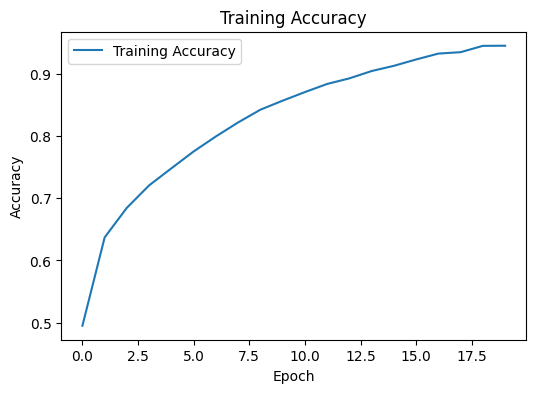

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.show()


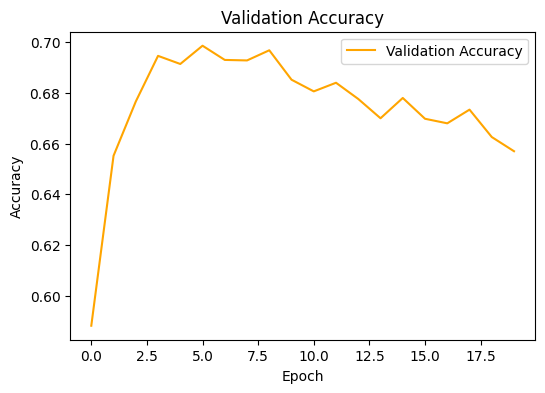

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.show()


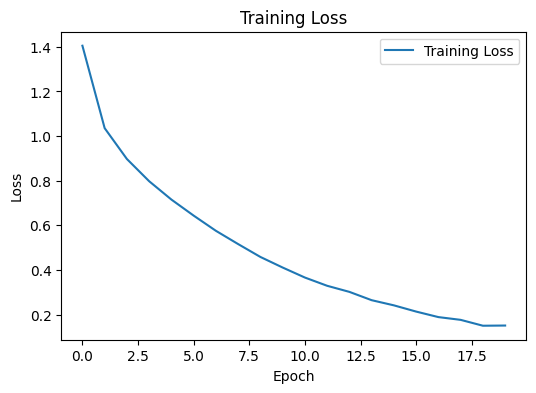

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.show()


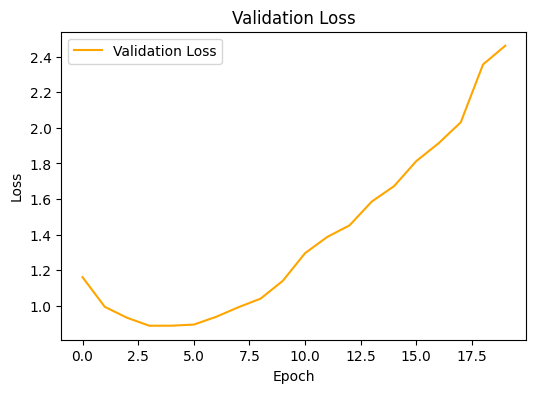

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.show()


**Inference:**
1. Training accuracy steadily increases across epochs as the model fits the training data.
2. Validation accuracy typically rises then plateaus, indicating the point beyond which the model gains little generalization benefit.
3. Training loss decreases monotonically, showing the optimizer is successfully minimizing the objective.
4. If validation loss starts increasing while training loss keeps falling, that gap signals the onset of overfitting.


## Task 7: Evaluate the Model
Accuracy, Precision, Recall, F1-score, Confusion Matrix, Classification Report


In [ ]:
y_pred_probs = model.predict(x_test_norm, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Test Accuracy : {acc:.4f}")
print(f"Precision (macro): {prec:.4f}")
print(f"Recall (macro)   : {rec:.4f}")
print(f"F1-score (macro) : {f1:.4f}")


Test Accuracy : 0.6436
Precision (macro): 0.6559
Recall (macro)   : 0.6436
F1-score (macro) : 0.6404


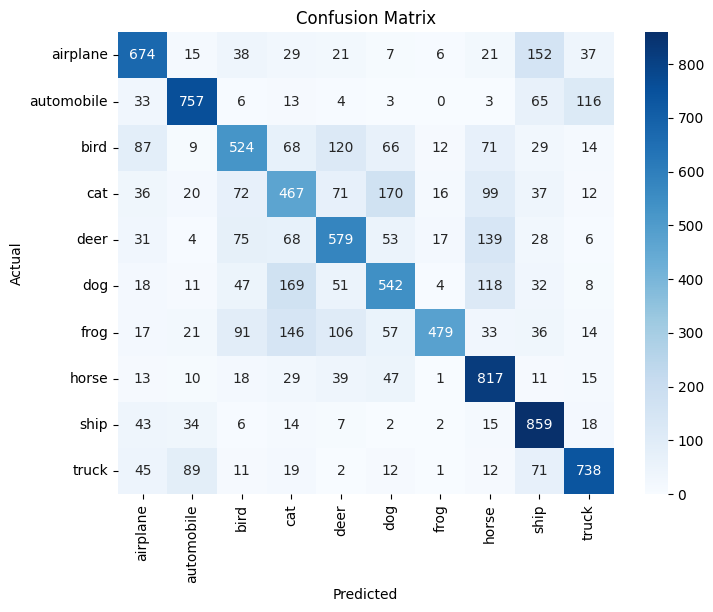

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


**Inference:** The diagonal dominance of the confusion matrix indicates most predictions are correct; the largest off-diagonal values typically occur between visually similar classes (e.g. cat/dog, automobile/truck), showing where the model confuses semantically close categories.

In [ ]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))


Classification Report:

              precision    recall  f1-score   support

    airplane       0.68      0.67      0.68      1000
  automobile       0.78      0.76      0.77      1000
        bird       0.59      0.52      0.56      1000
         cat       0.46      0.47      0.46      1000
        deer       0.58      0.58      0.58      1000
         dog       0.57      0.54      0.55      1000
        frog       0.89      0.48      0.62      1000
       horse       0.62      0.82      0.70      1000
        ship       0.65      0.86      0.74      1000
       truck       0.75      0.74      0.75      1000

    accuracy                           0.64     10000
   macro avg       0.66      0.64      0.64     10000
weighted avg       0.66      0.64      0.64     10000



## Additional Exercises

**Exercise 3: Compare ReLU and Sigmoid Activation Functions**

Train two small CNNs identical except for the activation function used after each convolution layer, and compare their training behaviour.


In [ ]:
relu_model = build_cnn()

sigmoid_model = models.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Conv2D(32,(3,3),activation='sigmoid',padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='sigmoid',padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='sigmoid'),
    layers.Dense(10,activation='softmax')
])

sigmoid_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**Inference:** ReLU typically converges faster and reaches higher accuracy than Sigmoid within the same number of epochs because it avoids the vanishing-gradient problem that Sigmoid suffers from in deeper networks.

**Exercise 4:** Already addressed above — the Average Pooling variant of the CNN was trained and its test accuracy compared with the Max Pooling model.

**Exercise 5: Increase Filters from 16 to 64**


In [ ]:
import time

# Model with 16 filters
model16 = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model16.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

start = time.time()

model16.fit(
    x_train_norm,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

time16 = time.time() - start
loss16, acc16 = model16.evaluate(x_test_norm, y_test, verbose=0)


# Model with 64 filters
model64 = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model64.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

start = time.time()

model64.fit(
    x_train_norm,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

time64 = time.time() - start
loss64, acc64 = model64.evaluate(x_test_norm, y_test, verbose=0)


print("16 Filters")
print("Test Accuracy:", round(acc16, 4))
print("Training Time:", round(time16, 2), "seconds")

print("\n64 Filters")
print("Test Accuracy:", round(acc64, 4))
print("Training Time:", round(time64, 2), "seconds")

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.4681 - loss: 1.4788 - val_accuracy: 0.5672 - val_loss: 1.2441
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5946 - loss: 1.1513 - val_accuracy: 0.6176 - val_loss: 1.1140
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6458 - loss: 1.0105 - val_accuracy: 0.6566 - val_loss: 1.0073
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6791 - loss: 0.9162 - val_accuracy: 0.6736 - val_loss: 0.9567
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7071 - loss: 0.8393 - val_accuracy: 0.6802 - val_loss: 0.9444
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.5012 - loss: 1.3924 - val_accuracy: 0.6042 - val_loss: 1.1237
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6481 - loss: 1.0038 - val_accuracy: 0.6524 - val_loss: 0.9738
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7011 - loss: 0.8559 - val_a

**Inference:** Increasing the number of filters from 16 to 64 generally improves accuracy because the network can learn a richer set of features, but it also increases the number of trainable parameters and computation time proportionally.

## Results Summary

Record the following in your lab report:

| Metric | Value |
|---|---|
| Training Accuracy | *(fill from history.history['accuracy'][-1])* |
| Testing Accuracy | *(printed above)* |
| Precision (macro) | *(printed above)* |
| Recall (macro) | *(printed above)* |
| F1-score (macro) | *(printed above)* |
| Total Trainable Parameters | *(see `model.summary()` above)* |


In [ ]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])
print("Total trainable parameters in model:", model.count_params())


Final Training Accuracy: 0.9455999732017517
Final Validation Accuracy: 0.6570000052452087
Total trainable parameters in model: 545098


## Discussion Questions

**1. Why is convolution preferred over fully connected layers for images?**
Convolution uses local, weight-shared filters that exploit the spatial structure of images, drastically reducing the number of parameters compared to a fully connected layer while preserving translation invariance — a fully connected layer would need a separate weight for every pixel-to-neuron connection, which does not scale to large images and ignores spatial locality.

**2. How does stride affect the feature map size?**
A larger stride moves the kernel by more pixels at each step, producing a smaller output feature map and reducing spatial resolution; stride 2 roughly halves the output dimensions compared to stride 1 (for the same kernel and padding).

**3. What is the role of padding?**
Padding adds extra pixels (usually zeros) around the input border so that the kernel can be applied to edge pixels properly; 'same' padding keeps the output size equal to the input size, while 'valid' padding (no padding) shrinks the output and can cause loss of border information over multiple layers.

**4. Why is pooling used?**
Pooling reduces the spatial dimensions of feature maps, which decreases computation and the number of parameters in later layers, introduces a degree of translation invariance, and helps control overfitting.

**5. How do feature maps represent image characteristics?**
Each feature map is the response of a specific learned filter across the image; early-layer feature maps typically capture low-level characteristics such as edges and colour blobs, while deeper-layer feature maps capture increasingly abstract, high-level patterns relevant to the classification task.

**6. Why do CNNs require fewer parameters than MLPs?**
CNNs share the same small set of kernel weights across all spatial locations (weight sharing) and connect each output only to a local receptive field (sparse connectivity), whereas an MLP fully connects every input pixel to every neuron, resulting in a vastly larger number of parameters for the same input size.


## References
1. Goodfellow et al., *Deep Learning*.
2. Bishop, *Pattern Recognition and Machine Learning*.
3. Haykin, *Neural Networks and Learning Machines*.
4. TensorFlow Documentation.
5. CIFAR-10 Dataset Documentation.
